In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as sig
import tensorflow as tf
import pywt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalAveragePooling1D, LSTM, Flatten, Bidirectional
from tensorflow.keras.models import Sequential
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import seaborn as sns

In [2]:
# Load your test datasets
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')
X_train = np.load('TEST1/X_train.npy')
y_train = np.load('TEST1/y_train.npy')

In [3]:
# Encode the labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

C:\Users\user\AppData\Local\Temp\ipykernel_17904\3860742871.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


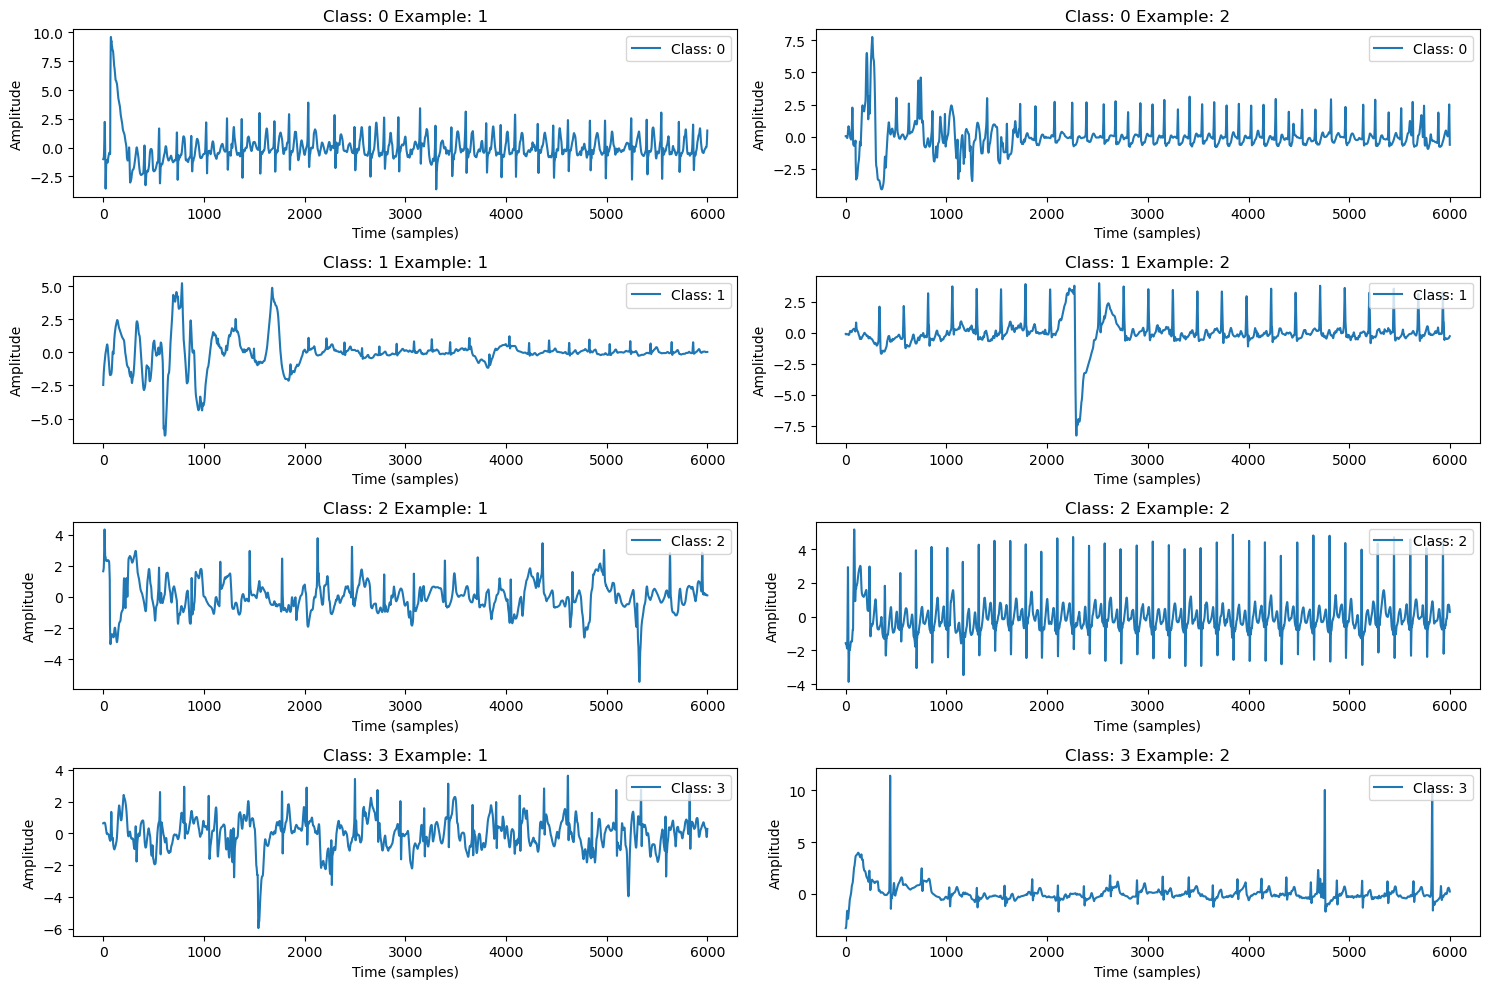

In [4]:
def plot_signal_per_class(X, y, label_encoder, num_examples=1):
    # Get unique classes
    unique_classes = np.unique(y)
    # Reverse mapping of labels to class names
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    plt.figure(figsize=(15, 10))
    for i, class_label in enumerate(unique_classes):
        indices = np.where(y == class_label)[0]
        for j in range(min(num_examples, len(indices))):
            index = indices[j]
            plt.subplot(len(unique_classes), num_examples, i * num_examples + j + 1)
            plt.plot(X[index].squeeze(), label=f'Class: {reverse_label_mapping[class_label]}')
            plt.legend(loc='upper right')
            plt.title(f'Class: {reverse_label_mapping[class_label]} Example: {j+1}')
            plt.xlabel('Time (samples)')
            plt.ylabel('Amplitude')
            plt.tight_layout()

    plt.show()

# Call the function to plot a signal from each class
plot_signal_per_class(X_train, y_train, label_encoder, num_examples=2)

In [5]:
# Perform stratified k-fold cross-validation, build and evaluate the model on each fold
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

train_accuracies, val_accuracies, test_accuracies = [], [], []

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {fold + 1}/{num_folds}")
    X_train_fold, X_val = X_train[train_index], X_train[val_index]
    y_train_fold, y_val = y_train[train_index], y_train[val_index]

    # Build the model
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=8, kernel_size=5, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=16, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=32, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=128, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=256, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=512, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Bidirectional(LSTM(128, return_sequences=True)),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
    ])


    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
    )

    train_accuracy = model.evaluate(X_train, y_train, verbose=0)[1]
    val_accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]

    print(f"Training Accuracy: {train_accuracy}, Validation Accuracy: {val_accuracy}, Test Accuracy: {test_accuracy}")

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)

Fold 1/10


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.5397 - loss: 1.0119 - val_accuracy: 0.6790 - val_loss: 0.7826
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.6816 - loss: 0.7670 - val_accuracy: 0.7262 - val_loss: 0.6949
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.7313 - loss: 0.6686 - val_accuracy: 0.7879 - val_loss: 0.5743
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.7677 - loss: 0.6177 - val_accuracy: 0.7980 - val_loss: 0.5490
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8006 - loss: 0.5518 - val_accuracy: 0.8204 - val_loss: 0.4970
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8006 - loss: 0.5238 - val_accuracy: 0.8373 - val_loss: 0.4527
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8192 - loss: 0.4884 - val_accuracy: 0.8552 - val_loss: 0.4418
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8384 - loss: 0

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9827 - loss: 0.0535 - val_accuracy: 0.9832 - val_loss: 0.0425
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9601 - loss: 0.1189 - val_accuracy: 0.9877 - val_loss: 0.0373
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9800 - loss: 0.0593 - val_accuracy: 0.9820 - val_loss: 0.0500
Training Accuracy: 0.9866352081298828, Validation Accuracy: 0.982042670249939, Test Accuracy: 0.9631127119064331
Fold 3/10
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.5458 - loss: 1.0150 - val_accuracy: 0.6633 - val_loss: 0.7798
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.6857 - loss: 0.7744 - val_accuracy: 0.7363 - val_loss: 0.6246
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.7370 - loss: 0.6577 - val_accuracy: 0.7755 - val_loss: 0.5726
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.7830 - loss: 0.5612 - val_accur

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9771 - loss: 0.0631 - val_accuracy: 0.9899 - val_loss: 0.0302
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9845 - loss: 0.0448 - val_accuracy: 0.9933 - val_loss: 0.0213
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9879 - loss: 0.0367 - val_accuracy: 0.9809 - val_loss: 0.0411
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9821 - loss: 0.0506 - val_accuracy: 0.9832 - val_loss: 0.0461
Epoch 48/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9732 - loss: 0.0755 - val_accuracy: 0.9607 - val_loss: 0.0967
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.9769 - loss: 0.0661 - val_accuracy: 0.9921 - val_loss: 0.0270
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9882 - loss: 0.0316 - val_accuracy: 0.9933 - val_loss: 0.0225
Training Accuracy: 0.9928122162818909, Validation Accuracy: 0.9932659864425659, Test Acc

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9752 - loss: 0.0720 - val_accuracy: 0.9775 - val_loss: 0.0536
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.9666 - loss: 0.1065 - val_accuracy: 0.9764 - val_loss: 0.0667
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9763 - loss: 0.0689 - val_accuracy: 0.9888 - val_loss: 0.0323
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9794 - loss: 0.0599 - val_accuracy: 0.9865 - val_loss: 0.0434
Epoch 44/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9859 - loss: 0.0398 - val_accuracy: 0.9888 - val_loss: 0.0322
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9887 - loss: 0.0349 - val_accuracy: 0.9899 - val_loss: 0.0263
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9885 - loss: 0.0336 - val_accuracy: 0.9809 - val_loss: 0.0484
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9777 - loss: 0.064

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9757 - loss: 0.0710 - val_accuracy: 0.9708 - val_loss: 0.0778
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9744 - loss: 0.0720 - val_accuracy: 0.9652 - val_loss: 0.0905
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9682 - loss: 0.0925 - val_accuracy: 0.9820 - val_loss: 0.0558
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9761 - loss: 0.0662 - val_accuracy: 0.9618 - val_loss: 0.0952
Epoch 40/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9729 - loss: 0.0825 - val_accuracy: 0.9820 - val_loss: 0.0460
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9813 - loss: 0.0579 - val_accuracy: 0.9742 - val_loss: 0.0536
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9755 - loss: 0.0680 - val_accuracy: 0.9809 - val_loss: 0.0511
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9829 - loss: 0.050

140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9619 - loss: 0.1106 - val_accuracy: 0.9596 - val_loss: 0.0937
Epoch 33/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9611 - loss: 0.1047 - val_accuracy: 0.9674 - val_loss: 0.0881
Epoch 34/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9599 - loss: 0.1101 - val_accuracy: 0.9551 - val_loss: 0.1105
Epoch 35/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9604 - loss: 0.1128 - val_accuracy: 0.9708 - val_loss: 0.0768
Epoch 36/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9619 - loss: 0.1056 - val_accuracy: 0.9753 - val_loss: 0.0645
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9642 - loss: 0.0955 - val_accuracy: 0.9607 - val_loss: 0.0839
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9654 - loss: 0.0991 - val_accuracy: 0.9674 - val_loss: 0.0838
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9704 - loss: 0.090

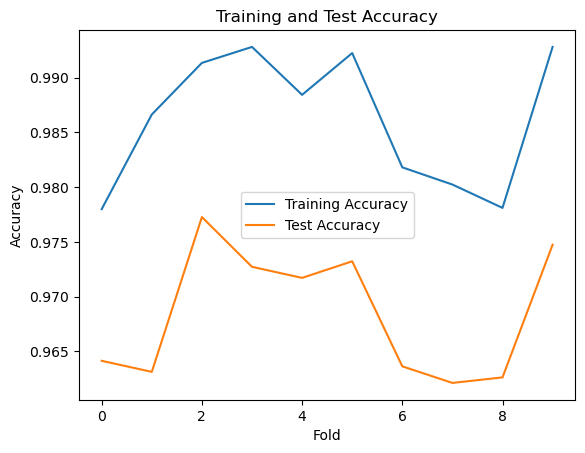

In [6]:
# Plot the training and test accuracies for each fold
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.show()

In [7]:
# Calculate the mean accuracies for training and test sets
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)


print(f"Mean Test Accuracy: {mean_test_accuracy} ")
print(f"Mean Training Accuracy: {mean_train_accuracy} ")

Mean Test Accuracy: 0.9685194551944732 
Mean Training Accuracy: 0.9862421333789826 


In [8]:
# Predict labels for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert class labels to strings for classification_report
target_names = [str(i) for i in label_encoder.classes_]

# Generate classification report
report = classification_report(y_test, y_pred_classes, target_names=target_names)

# Print classification report
print(report)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       185
           1       0.97      0.99      0.98      1137
           2       0.97      0.96      0.96       627
           3       1.00      0.90      0.95        30

    accuracy                           0.97      1979
   macro avg       0.98      0.95      0.97      1979
weighted avg       0.97      0.97      0.97      1979



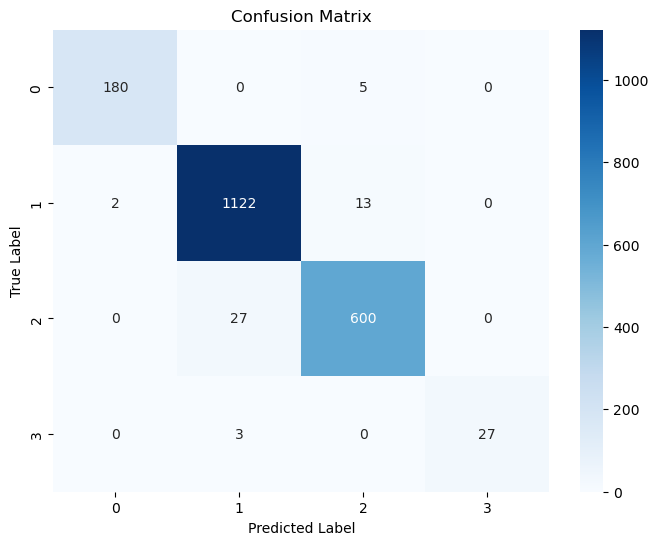

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [10]:
# Define the path to the folder
folder_path = "MODElS"

# Define the full path including the folder and filename
model_path = os.path.join(folder_path, "CNNbi10.h5")

# Save the model
model.save(model_path)

In [11]:
from tensorflow.keras.models import load_model
model_path = 'MODElS/CNNbi10.h5'
loaded_model = load_model(model_path)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


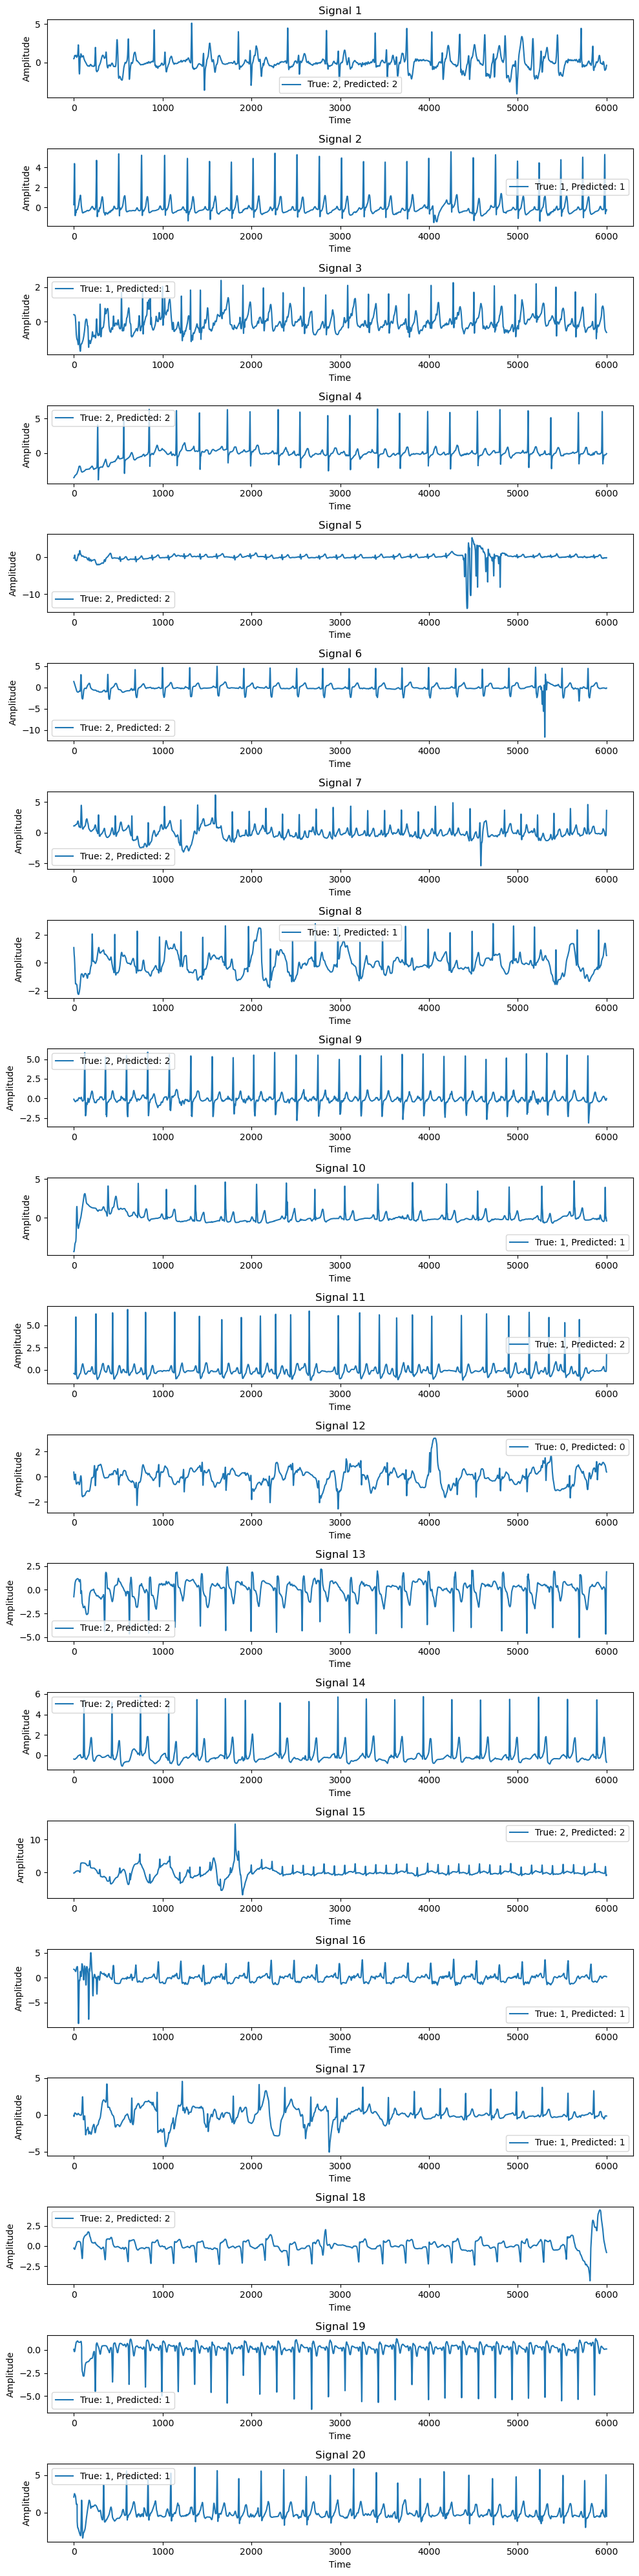

Correct Predictions: 1929
Incorrect Predictions: 50


In [12]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, label_encoder, num_samples=10):
    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct

    # Reverse label mapping
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i].squeeze()  # Squeeze to convert (N, 1) to (N,)
        true_label = reverse_label_mapping[y_test[i]]
        predicted_label = reverse_label_mapping[predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")

# Example usage:
# Assuming 'model', 'X_test', 'y_test', and 'label_encoder' are already defined
plot_and_predict(X_test, y_test, loaded_model, label_encoder, num_samples=20)